In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

sns.set(style="whitegrid")


In [ ]:
##Loading datasets

In [2]:
bat = pd.read_csv("batting_summary.csv")
bowl = pd.read_csv("bowling_summary.csv")
match = pd.read_csv("match_schedule_results.csv")
players = pd.read_csv("world_cup_players_info.csv")

In [ ]:
##Checking 1st row

In [3]:
bat.head()


,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


In [4]:
bowl.head()

,Match_no,Match_Between,Bowling_Team,Bowler_Name,Overs,Maidens,Runs,Wickets,Economy
0,1,England vs New Zealand,New Zealand,Trent Boult,10.0,1,48,1,4.8
1,1,England vs New Zealand,New Zealand,Matt Henry,10.0,1,48,3,4.8
2,1,England vs New Zealand,New Zealand,Mitchell Santner,10.0,0,37,2,3.7
3,1,England vs New Zealand,New Zealand,Jimmy Neesham,7.0,0,56,0,8.0
4,1,England vs New Zealand,New Zealand,Rachin Ravindra,10.0,0,76,1,7.6


In [5]:

match.head()


,Match_no,Date,Venue,Team1,Team2,Winner,Scorecard URL
0,1,October 5,Ahmedabad,England,New Zealand,New Zealand,https://www.cricketwa.com/scorecard/18020/engl...
1,2,October 6,Hyderabad,Pakistan,Netherlands,Pakistan,https://www.cricketwa.com/scorecard/18021/paki...
2,3,October 7,Dharamsala,Bangladesh,Afghanistan,Bangladesh,https://www.cricketwa.com/scorecard/23008/bang...
3,4,October 7,Delhi,South Africa,Sri Lanka,South Africa,https://www.cricketwa.com/scorecard/23009/sout...
4,5,October 8,Chennai,India,Australia,India,https://www.cricketwa.com/scorecard/23010/indi...


In [6]:
players.head()

,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


In [ ]:
###Inspecting datasets

In [7]:
bat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Match_no          916 non-null    int64 
 1   Match_Between     916 non-null    object
 2   Team_Innings      916 non-null    object
 3   Batsman_Name      916 non-null    object
 4   Batting_Position  916 non-null    int64 
 5   Dismissal         914 non-null    object
 6   Runs              916 non-null    int64 
 7   Balls             916 non-null    int64 
 8   4s                916 non-null    int64 
 9   6s                916 non-null    int64 
 10  Strike_Rate       916 non-null    object
dtypes: int64(6), object(5)
memory usage: 78.8+ KB


In [8]:
bowl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Match_no       574 non-null    int64  
 1   Match_Between  574 non-null    object 
 2   Bowling_Team   574 non-null    object 
 3   Bowler_Name    574 non-null    object 
 4   Overs          574 non-null    float64
 5   Maidens        574 non-null    int64  
 6   Runs           574 non-null    int64  
 7   Wickets        574 non-null    int64  
 8   Economy        574 non-null    float64
dtypes: float64(2), int64(4), object(3)
memory usage: 40.5+ KB


In [9]:
match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Match_no       48 non-null     int64 
 1   Date           48 non-null     object
 2   Venue          48 non-null     object
 3   Team1          48 non-null     object
 4   Team2          48 non-null     object
 5   Winner         48 non-null     object
 6   Scorecard URL  48 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.8+ KB


In [10]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   player_name      151 non-null    object
 1   team_name        151 non-null    object
 2   image_of_player  85 non-null     object
 3   battingStyle     151 non-null    object
 4   bowlingStyle     145 non-null    object
 5   playingRole      151 non-null    object
 6   description      134 non-null    object
dtypes: object(7)
memory usage: 8.4+ KB


In [11]:
##Checking missing values

In [12]:
bat.isnull().sum()

Match_no            0
Match_Between       0
Team_Innings        0
Batsman_Name        0
Batting_Position    0
Dismissal           2
Runs                0
Balls               0
4s                  0
6s                  0
Strike_Rate         0
dtype: int64

In [13]:
bowl.isnull().sum()

Match_no         0
Match_Between    0
Bowling_Team     0
Bowler_Name      0
Overs            0
Maidens          0
Runs             0
Wickets          0
Economy          0
dtype: int64

In [14]:
match.isnull().sum()

Match_no         0
Date             0
Venue            0
Team1            0
Team2            0
Winner           0
Scorecard URL    0
dtype: int64

In [15]:
players.isnull().sum()

player_name         0
team_name           0
image_of_player    66
battingStyle        0
bowlingStyle        6
playingRole         0
description        17
dtype: int64

In [16]:
##Dataset shape

In [17]:
bat.shape

(916, 11)

In [18]:
bowl.shape

(574, 9)

In [19]:
match.shape

(48, 7)

In [20]:
players.shape

(151, 7)

In [21]:
##Data cleaning

In [22]:
bat["Runs"] = pd.to_numeric(bat["Runs"], errors="coerce")
bat["Balls"] = pd.to_numeric(bat["Balls"], errors="coerce")
bat["Strike_Rate"] = pd.to_numeric(bat["Strike_Rate"], errors="coerce")

In [23]:
bowl["Overs"] = pd.to_numeric(bowl["Overs"], errors="coerce")
bowl["Runs"] = pd.to_numeric(bowl["Runs"], errors="coerce")
bowl["Wickets"] = pd.to_numeric(bowl["Wickets"], errors="coerce")
bowl["Economy"] = pd.to_numeric(bowl["Economy"], errors="coerce")

In [24]:
bat.head()

,Match_no,Match_Between,Team_Innings,Batsman_Name,Batting_Position,Dismissal,Runs,Balls,4s,6s,Strike_Rate
0,1,England vs New Zealand,England,Jonny Bairstow,1,c Daryl Mitchell b Mitchell Santner,33,35,4,1,94.3
1,1,England vs New Zealand,England,Dawid Malan,2,c Tom Latham b Matt Henry,14,24,2,0,58.3
2,1,England vs New Zealand,England,Joe Root,3,b Glenn Phillips,77,86,4,1,89.5
3,1,England vs New Zealand,England,Harry Brook,4,c Devon Conway b Rachin Ravindra,25,16,4,1,156.3
4,1,England vs New Zealand,England,Moeen Ali,5,b Glenn Phillips,11,17,1,0,64.7


In [25]:
#Filling missing values

In [26]:
bat.fillna(0, inplace=True)
bowl.fillna(0, inplace=True)

In [27]:
##creating features

In [ ]:
#Boundary runs

In [28]:
bat["Boundary_Runs"] = (bat["4s"] * 4) + (bat["6s"] * 6)

In [ ]:
#Batting impact score

In [29]:
bat["Batting_Impact"] = bat["Runs"] * (bat["Strike_Rate"] / 100)

In [ ]:
##Bowling impact score

In [31]:
bowl["Bowling_Impact"] = bowl["Wickets"] * (6 - bowl["Economy"])

In [32]:
##Exploratory Data Analysis

In [ ]:
#Top run scorer

In [33]:
top_runs = bat.groupby("Batsman_Name")["Runs"].sum().sort_values(ascending=False).head(10)
top_runs

Batsman_Name
Virat Kohli              765
Quinton de Kock          706
Rohit Sharma             597
Rachin Ravindra          578
David Warner             577
Daryl Mitchell           552
Shreyas Iyer             530
Rassie van der Dussen    480
David Miller             474
Aiden Markram            472
Name: Runs, dtype: int64

In [34]:
#Top wicket takers

In [35]:
top_wickets = bowl.groupby("Bowler_Name")["Wickets"].sum().sort_values(ascending=False).head(10)
top_wickets

Bowler_Name
Mohammed Shami        24
Adam Zampa            23
Dilshan Madushanka    21
Jasprit Bumrah        20
Gerald Coetzee        20
Shaheen Afridi        18
Marco Jansen          17
Josh Hazlewood        16
Mitchell Starc        16
Haris Rauf            16
Name: Wickets, dtype: int64

In [36]:
##Team wins

In [37]:
team_wins = match["Winner"].value_counts()
team_wins

Winner
India           9
Australia       9
South Africa    7
New Zealand     5
Pakistan        4
Afghanistan     4
England         3
Sri Lanka       3
Bangladesh      2
Netherlands     2
Name: count, dtype: int64

In [38]:
##Data Visualization

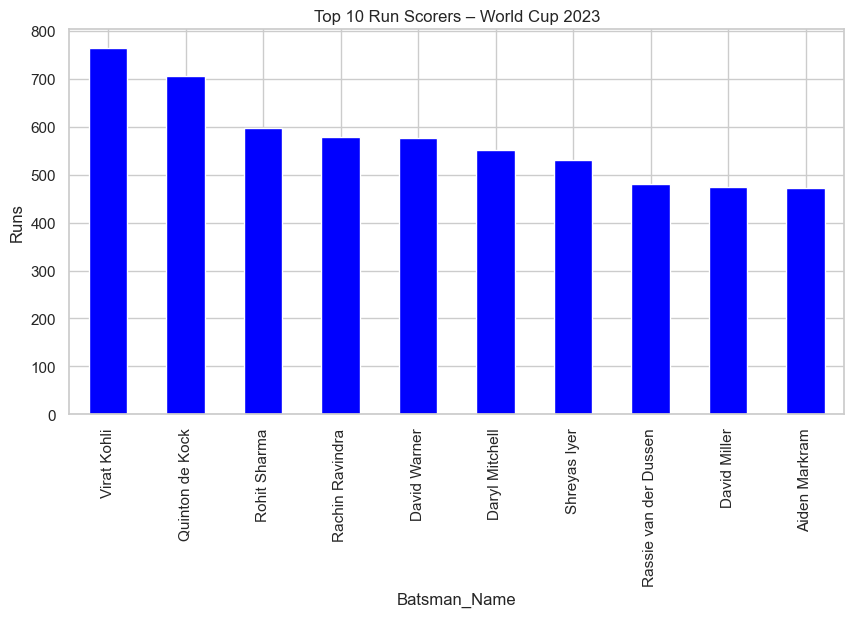

In [39]:
plt.figure(figsize=(10,5))
top_runs.plot(kind="bar", color="blue")
plt.title("Top 10 Run Scorers – World Cup 2023")
plt.ylabel("Runs")
plt.show()

In [40]:
#Top wicket takers

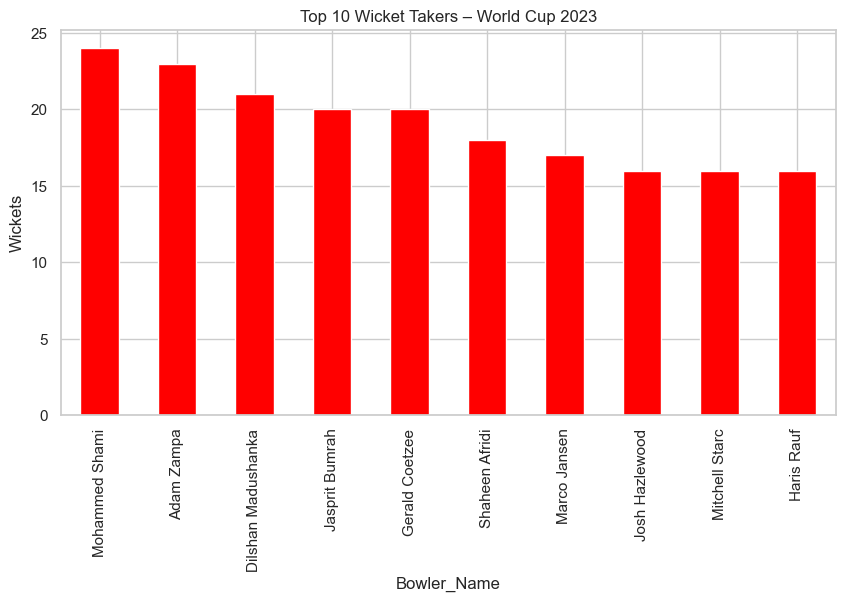

In [41]:
plt.figure(figsize=(10,5))
top_wickets.plot(kind="bar", color="red")
plt.title("Top 10 Wicket Takers – World Cup 2023")
plt.ylabel("Wickets")
plt.show()

In [42]:
##Runs distribution

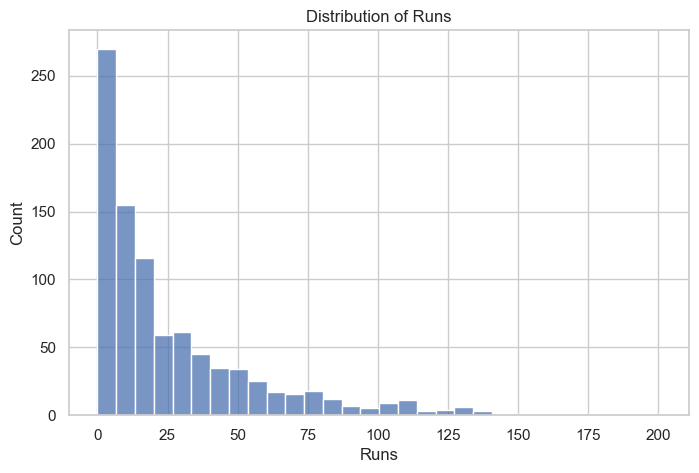

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(bat["Runs"], bins=30)
plt.title("Distribution of Runs")
plt.show()

In [44]:
#Economy rate distribution

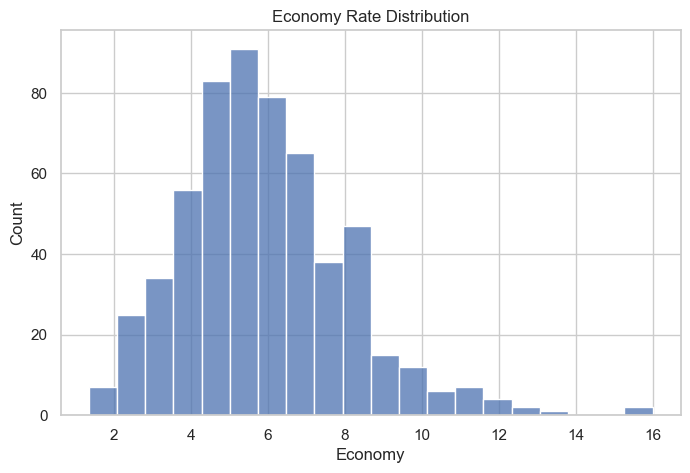

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(bowl["Economy"], bins=20)
plt.title("Economy Rate Distribution")
plt.show()

In [46]:
#coorelation heatmap

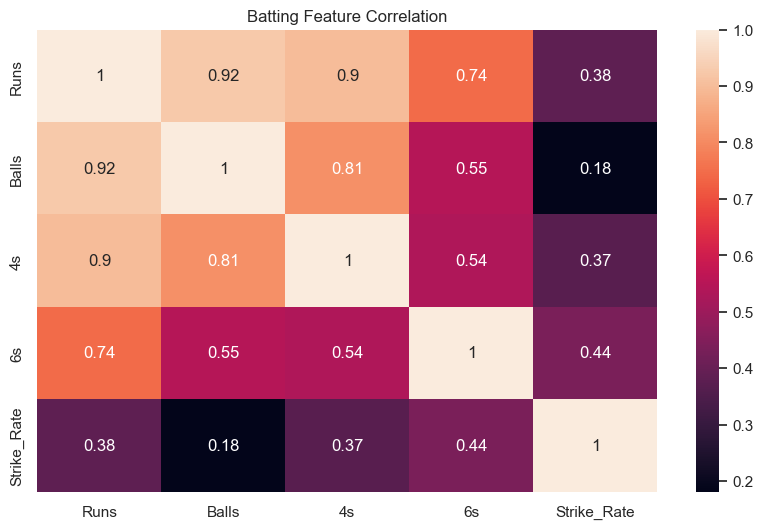

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(bat[["Runs","Balls","4s","6s","Strike_Rate"]].corr(), annot=True)
plt.title("Batting Feature Correlation")
plt.show()

In [48]:
#merging dataset playerrole

In [49]:
bat_role = bat.merge(players, left_on="Batsman_Name", right_on="player_name", how="left")

In [50]:
bat_role["playingRole"].value_counts()

playingRole
Top order Batter       225
Bowler                 192
Wicketkeeper Batter    123
Allrounder             121
Opening Batter          63
Middle order Batter     63
Batting Allrounder      58
                        43
Bowling Allrounder      15
Batter                  13
Name: count, dtype: int64

In [51]:
##Machine learning models 

In [52]:
#Predicting Runs Using Random Forest

In [53]:
features = bat[["Balls","4s","6s","Strike_Rate"]]
target = bat["Runs"]

In [54]:
#Train split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [56]:
#Train model

In [57]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [58]:
#predict

In [59]:
pred = model.predict(X_test)

In [60]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 2.544890020686809


In [61]:
##Predict Match Winner (Classification)

In [62]:
match_model = match[["Team1","Team2","Winner"]].dropna()

le = LabelEncoder()

match_model["Team1"] = le.fit_transform(match_model["Team1"])
match_model["Team2"] = le.fit_transform(match_model["Team2"])
match_model["Winner"] = le.fit_transform(match_model["Winner"])

In [63]:
#split

In [64]:
X = match_model[["Team1","Team2"]]
y = match_model["Winner"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [65]:
#train classifier

In [66]:
clf = RandomForestClassifier()
clf.fit(X_train,y_train)

RandomForestClassifier()

In [67]:
##Accuracy

In [68]:
pred = clf.predict(X_test)
accuracy_score(y_test,pred)

0.3

In [71]:
##Best 11 selection

In [ ]:
#Top batsman

In [70]:
best_batsmen = bat.groupby("Batsman_Name")["Runs"].sum().sort_values(ascending=False).head(6)
best_batsmen

Batsman_Name
Virat Kohli        765
Quinton de Kock    706
Rohit Sharma       597
Rachin Ravindra    578
David Warner       577
Daryl Mitchell     552
Name: Runs, dtype: int64

In [72]:
#Top bowlers

In [73]:
best_bowlers = bowl.groupby("Bowler_Name")["Wickets"].sum().sort_values(ascending=False).head(5)
best_bowlers

Bowler_Name
Mohammed Shami        24
Adam Zampa            23
Dilshan Madushanka    21
Jasprit Bumrah        20
Gerald Coetzee        20
Name: Wickets, dtype: int64

In [74]:
#Combine

In [75]:
best_team = list(best_batsmen.index) + list(best_bowlers.index)
best_team

['Virat Kohli',
 'Quinton de Kock',
 'Rohit Sharma',
 'Rachin Ravindra',
 'David Warner',
 'Daryl Mitchell',
 'Mohammed Shami',
 'Adam Zampa',
 'Dilshan Madushanka',
 'Jasprit Bumrah',
 'Gerald Coetzee']

In [76]:
#Saving reults

In [77]:
top_runs.to_csv("top_batsmen.csv")
top_wickets.to_csv("top_bowlers.csv")

In [78]:
#Player clustering

In [79]:
player_stats = bat.groupby("Batsman_Name").agg({
    "Runs":"sum",
    "Balls":"sum",
    "4s":"sum",
    "6s":"sum",
    "Strike_Rate":"mean"
}).reset_index()

player_stats.head()

,Batsman_Name,Runs,Balls,4s,6s,Strike_Rate
0,Abdullah Shafique,336,360,36,9,71.388875
1,Adam Zampa,59,76,6,0,74.304571
2,Adil Rashid,92,91,7,2,91.632556
3,Agha Salman,51,45,6,1,113.333000
4,Aiden Markram,472,430,53,10,141.043000


In [80]:
from sklearn.preprocessing import StandardScaler

features = player_stats[["Runs","Balls","4s","6s","Strike_Rate"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

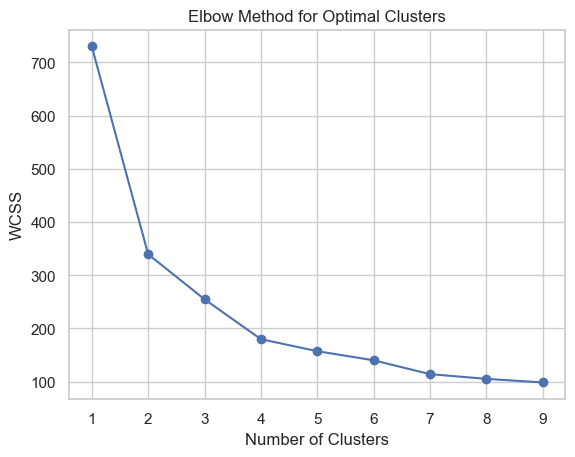

In [82]:
plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [83]:
##Applying K-means

In [84]:
kmeans = KMeans(n_clusters=4, random_state=42)

player_stats["Cluster"] = kmeans.fit_predict(scaled_features)

player_stats.head()

C:\Users\Kunal\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Batsman_Name,Runs,Balls,4s,6s,Strike_Rate,Cluster
0,Abdullah Shafique,336,360,36,9,71.388875,1
1,Adam Zampa,59,76,6,0,74.304571,0
2,Adil Rashid,92,91,7,2,91.632556,3
3,Agha Salman,51,45,6,1,113.333000,3
4,Aiden Markram,472,430,53,10,141.043000,2


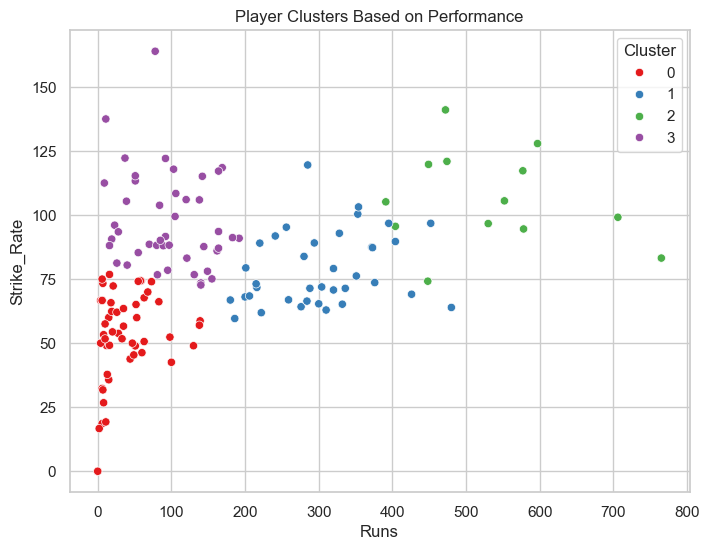

In [85]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=player_stats["Runs"],
    y=player_stats["Strike_Rate"],
    hue=player_stats["Cluster"],
    palette="Set1"
)

plt.title("Player Clusters Based on Performance")
plt.show()

In [86]:
#Feature Importance Using SHAP

In [93]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [88]:
#Train Model Again

In [94]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

  Feature  Importance
0   Team1    0.680401
1   Team2    0.319599


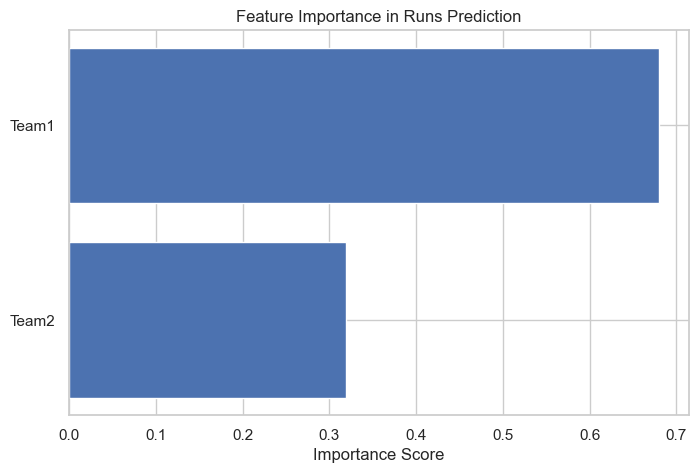

In [95]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance in Runs Prediction")
plt.gca().invert_yaxis()
plt.show()

In [96]:
##Optimization-Based Best XI

In [97]:
#Create player score

In [ ]:
#Batting

In [98]:
bat_total = bat.groupby("Batsman_Name").agg({
    "Runs":"sum",
    "Strike_Rate":"mean",
    "4s":"sum",
    "6s":"sum"
}).reset_index()

In [99]:
#Bowling

In [100]:
bowl_total = bowl.groupby("Bowler_Name").agg({
    "Wickets":"sum",
    "Economy":"mean"
}).reset_index()

In [101]:
##Batting score

In [102]:
bat_total["Batting_Score"] = (
    bat_total["Runs"]*0.6 +
    bat_total["Strike_Rate"]*0.3 +
    (bat_total["4s"]+bat_total["6s"])*0.1
)

In [103]:
##Bowling score

In [104]:
bowl_total["Bowling_Score"] = (
    bowl_total["Wickets"]*0.7 -
    bowl_total["Economy"]*0.3
)

In [105]:
##Selecting best players

In [106]:
#Top batsman

In [107]:
top_batsmen = bat_total.sort_values("Batting_Score", ascending=False).head(6)

In [108]:
top_batsmen.head()

,Batsman_Name,Runs,Strike_Rate,4s,6s,Batting_Score
143,Virat Kohli,765,83.210091,68,9,491.663027
103,Quinton de Kock,706,99.135250,65,26,462.440575
113,Rohit Sharma,597,127.904091,66,31,406.271227
21,David Warner,577,117.276846,53,28,389.483054
104,Rachin Ravindra,578,94.565700,55,17,382.369710


In [ ]:
#Top bowlers

In [109]:
top_bowlers = bowl_total.sort_values("Bowling_Score", ascending=False).head(5)

In [110]:
top_bowlers.head()

,Bowler_Name,Wickets,Economy,Bowling_Score
63,Mohammed Shami,24,5.141000,15.257700
0,Adam Zampa,23,5.293091,14.512073
33,Jasprit Bumrah,20,3.876182,12.837145
18,Dilshan Madushanka,21,6.790111,12.662967
23,Gerald Coetzee,20,6.445125,12.066463


In [111]:
#Constructing best 11

In [112]:
best_xi = list(top_batsmen["Batsman_Name"]) + list(top_bowlers["Bowler_Name"])

print("Optimized Best XI:")
print(best_xi)

Optimized Best XI:
['Virat Kohli', 'Quinton de Kock', 'Rohit Sharma', 'David Warner', 'Rachin Ravindra', 'Daryl Mitchell', 'Mohammed Shami', 'Adam Zampa', 'Jasprit Bumrah', 'Dilshan Madushanka', 'Gerald Coetzee']


In [113]:
##Visualisation 